In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import sys
sys.path.insert(1, '../')
from Harmonic_degree import *
from HOLR_functions import *
from Higher_order_harmonic_degree import *

In [2]:
# set colors
colors = ["#003F5C","#2F4B7C","#665191","#A05195","#D45087","#F95D6A","#FF7C43","#FFA600"]
colors_sequential = colors + colors + colors + colors 
colors = ["#02405c", "#fea600", "#a20655", "#5e96c5", "#4b3596", "#fa6ca9", "#8d6cf6"]
colors_curves = colors+ colors+ colors+ colors
col=colors_sequential[5]

In [3]:
## Code for parallel adjacency graph, this is just a modification of the higher order renormalization code for parallel adjacency 
def higher_order_renormalization_p(sc,t,dim,Lap, tresh=0):
    # sc is the simplicial complex
    # t is the time I want the clustering
    # dim is the dimension I want the clustering
    ### I am modifying the merging criteria, since rho_.J is exp(-tL) e_j , now I am doing exp(-tL) Proj_{Orthogonal of the Kernel}(e_j)
    # then I consider the average in absolute values between rho_ij and rho_ji
    
    # making the parallel adj graph
    Ag=nx.Graph()
    Ag.add_nodes_from([i for i in range(sc[f"n{dim}"])])
    for i in range(Lap.shape[0]):
        for j in range(Lap.shape[0]):
            if (i !=j and Lap[i,j]!=0):
                Ag.add_edge(i,j)

    if dim==0:
        title = "nodes"
    if dim == 1:
        title = "edges"
    if dim == 2:
        title = "faces"
    if dim ==3:
        title = "tetrahedra"
    if dim ==4:
        title = "4-simplices"

    eigvals, eigvecs = np.linalg.eigh(Lap)

    kernel_threshold = 1e-7
    ker_indices = np.where(np.abs(eigvals) < kernel_threshold)[0]
    ker_basis = eigvecs[:, ker_indices]

    # Projection into orthogonal of kernel
    P_perp = np.eye(Lap.shape[0]) - ker_basis @ ker_basis.T

    # Diffusing the non harmonic component
    rho = np.zeros_like(Lap, dtype=float)
    for j in range(Lap.shape[1]):
        e_j = np.zeros(Lap.shape[1])
        e_j[j] = 1.0
        v = P_perp @ e_j                
        u = scipy.linalg.expm(-t * Lap) @ v   
        rho[:, j] = u                         
    # In this setting the density is useless and has not the interpretation anymore as density matrix
    #density = rho / np.trace(rho)  

    Gv = nx.Graph()
    labels = {}
    n_nodes = sc[f"n{dim}"]
    Gv.add_nodes_from(range(n_nodes))

    for i in range(n_nodes):
        for j in range(i+1, n_nodes):
            avg_val = (np.abs(rho[i, j]) + np.abs(rho[j, i])) / 2
            if avg_val >= min(np.abs(rho[i, i]), np.abs(rho[j, j])) - tresh:
                Gv.add_edge(i, j)
        ob_i = sc[title][i]
        labels[i] = f"{ob_i}".replace("[", "").replace("]", "")

    # Compute connected components and store in clusters dictionary
    idx_components = {u: i for i, node_set in enumerate(nx.connected_components(Gv)) for u in node_set}
    clusters = {node: idx_components[node] for node in Gv.nodes()}  # Ensure clusters use Ag node labels
    #print(clusters)

    clist = list(mcolors.CSS4_COLORS.values()) * 10
    np.random.shuffle(clist)

    # Assign colors to clusters correctly
    cluster_ids = sorted(set(clusters.values()))  # Unique cluster IDs
    cluster_to_color = {cid: clist[i] for i, cid in enumerate(cluster_ids)}
    # Extract unique colors for clusters
    sing_col = [cluster_to_color[cid] for cid in cluster_ids]
    colors = {node: cluster_to_color[clusters[node]] for node in clusters}

    G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf = H_CF_cluster(Ag,clusters)
    return Ag,G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv, sing_col, colors
            




def higher_order_renormalization_series_p(sc,t_span,dim,Lap,tresh=0):
    g=[]
    DEG_H = []
    M_DEG_H = []
    STD_H = []
    AV_H = []
    STD_V_H = []
    NOT_H = []
    DEG_CF = []
    M_DEG_CF = []
    STD_CF = []
    AV_CF = []
    STD_V_CF = []
    NOT_CF = []
    gV = []
    
    for t in t_span:
        Ag,G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv, sing_col, colors=higher_order_renormalization_p(sc,t,dim,Lap,tresh)
        g.append(G)
        DEG_H.append(deg_h)
        M_DEG_H.append(M_deg_h)
        STD_H.append(std_h)
        AV_H.append(av_h)
        STD_V_H.append(std_v_h)
        NOT_H.append(Not_h)
        DEG_CF.append(deg_cf)
        M_DEG_CF.append(M_deg_cf)
        STD_CF.append(std_cf)
        AV_CF.append(av_cf)
        STD_V_CF.append(std_v_cf)
        NOT_CF.append(Not_cf)
        gV.append(Gv)
        
        
    return Ag, g, DEG_H, M_DEG_H, STD_H, AV_H, STD_V_H, NOT_H, DEG_CF, M_DEG_CF, STD_CF, AV_CF, STD_V_CF, NOT_CF, gV



def iter_g_higher_order_p(sc,dim,Lap,tresh=0):
    t=0.0
    l=0
    while((t<500) and (l!=1)):
        t=t+1.0
        G = higher_order_renormalization_p(sc,t,dim,Lap,tresh)[1]
        l=len(G.nodes())
    return t

def iter_narrow_g_higher_order_p(sc,dim,Lap,tresh=0):
    t_i=iter_g_higher_order_p(sc,dim,Lap,tresh)
    t=t_i-1.0
    l=0
    while((t<= t_i) and (l!=1)):
        t=t+0.1
        G= higher_order_renormalization_p(sc,t,dim,Lap,tresh)[1]
        l=len(G.nodes())
    return round(t,1)

def higher_order_H_CF_curves_p(sc,dim,Lap,n,tresh=0):
    t_f=iter_narrow_g_higher_order_p(sc,dim,Lap,tresh)
    t_i=0
    t_span=np.linspace(t_i,t_f,n)
    Ag, g, DEG_H, M_DEG_H, STD_H, AV_H, STD_V_H, NOT_H, DEG_CF, M_DEG_CF, STD_CF, AV_CF, STD_V_CF, NOT_CF, gV = higher_order_renormalization_series_p(sc,t_span,dim,Lap,tresh=0)
    return Ag, g, DEG_H, M_DEG_H, STD_H, AV_H, STD_V_H, NOT_H, DEG_CF, M_DEG_CF, STD_CF, AV_CF, STD_V_CF, NOT_CF, gV, t_span

# Pseudofractal

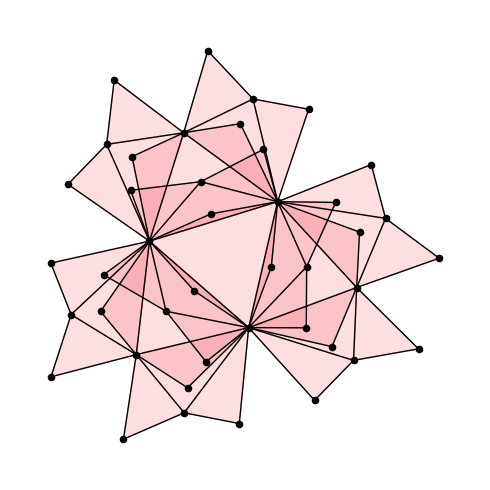

In [4]:
# building the graph, I am building an apollonian graph
#sc_model =NGF(3,50,0,beta =-2,M =1)
sc=pseudofractal_d2(3)
f,axs = plt.subplots(1,1,figsize = (5,5))
plot_complex(sc,ax = axs,face_color=[col],face_alpha=0.2,node_size=20,iterations=1000,with_labels=False)
plt.tight_layout()

In [5]:
# setting parameters for Entropic curves
exm = -2 # C curve starts from 10**taumin
exM = 5 # C curve ends at 10**taumax
n_t = 1000 # Number of times to consider in the interval

# I consider all the matrices I need
L0, L1, L2, L3, L4, node_dict, edge_dict, face_dict, tet_dict=laplacians(sc)
B1, F1 =fbc(L1)
B2, F2 =fbc(L2)
X1 = XO_laplacian(sc,1,0)
X2 = XO_laplacian(sc,2,1)

# computing curvature distributions
f1=np.diag(F1)
f2=np.diag(F2)
r2=int(np.max(f2)-np.min(f2))
r1=int(np.max(f1)-np.min(f1))

# computing eigenvalues
s1=L1.shape[0]
s2=L2.shape[0]
e1,ev1=np.linalg.eigh(L1)
e2,ev2=np.linalg.eigh(L2)
eb1,evb1=np.linalg.eigh(B1)
eb2,evb2=np.linalg.eigh(B2)
ex1,evx1=np.linalg.eigh(X1)
ex2,evx2=np.linalg.eigh(X2)


In [6]:
# computing entropic quantities: entropy and entropic subsceptibility
c2,t2,s2=compute_entropic_C(e2,exm,exM,n_t)
cb2,tb2,sb2=compute_entropic_C(eb2,exm,exM,n_t)
cx2,tx2,sx2 = compute_entropic_C(ex2,exm,exM,n_t)

# Computing spectral dimension
sd2,ts2=compute_spectral_d(e2,exm,exM,n_t)
sdb2,tsb2=compute_spectral_d(eb2,exm,exM,n_t)
sdx2,tsx2=compute_spectral_d(ex2,exm,exM,n_t)

c:\Users\Utente\Desktop\Harmonic_Morph_2\Higher_Order\..\HOLR_functions.py:305: RuntimeWarning: overflow encountered in exp
  mu[i] = 1 / np.sum(np.exp(-tau * (D - D[i])))
c:\Users\Utente\anaconda3\envs\Nuovo2_net\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\Utente\Desktop\Harmonic_Morph_2\Higher_Order\..\HOLR_functions.py:329: RuntimeWarning: divide by zero encountered in log
  dS = -2*np.diff(np.log(Z))/np.diff(np.log(tau_space))
c:\Users\Utente\anaconda3\envs\Nuovo2_net\lib\site-packages\numpy\lib\function_base.py:1452: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


In [7]:
Ag_h, g_h, DEG_H_h, M_DEG_H_h, STD_H_h, AV_H_h, STD_V_H_h, NOT_H_h, DEG_CF_h, M_DEG_CF_h, STD_CF_h, AV_CF_h, STD_V_CF_h, NOT_CF_h, gV_h, t_span_h = higher_order_H_CF_curves(sc,n=100,dim=2,Lap=L2)
Ag_b, g_b, DEG_H_b, M_DEG_H_b, STD_H_b, AV_H_b, STD_V_H_b, NOT_H_b, DEG_CF_b, M_DEG_CF_b, STD_CF_b, AV_CF_b, STD_V_CF_b, NOT_CF_b, gV_b, t_span_b = higher_order_H_CF_curves(sc,n=100,dim=2,Lap=B2)
Ag_x, g_x, DEG_H_x, M_DEG_H_x, STD_H_x, AV_H_x, STD_V_H_x, NOT_H_x, DEG_CF_x, M_DEG_CF_x, STD_CF_x, AV_CF_x, STD_V_CF_x, NOT_CF_x, gV_x, t_span_x = higher_order_H_CF_curves(sc,n=100,dim=2,Lap=X2)

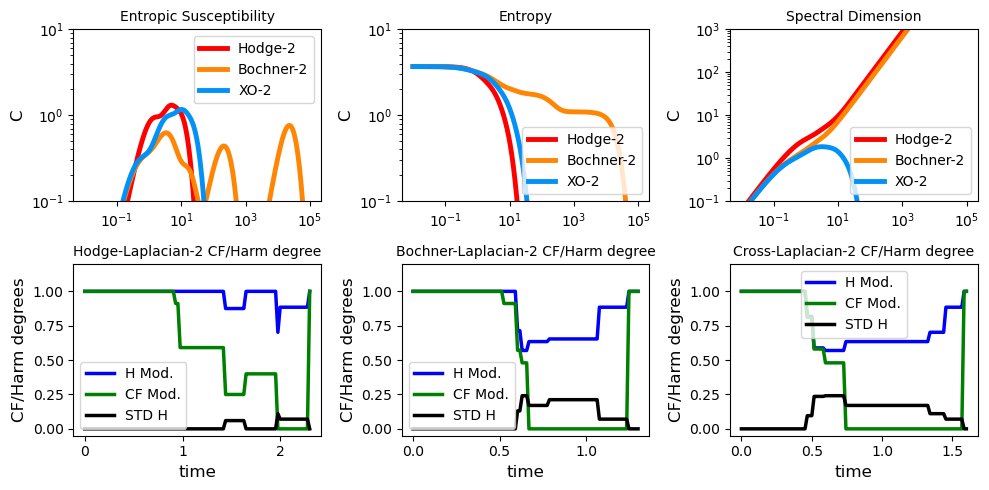

In [ ]:
# Plots
f,ax= plt.subplots(2,3,figsize=(10,5))
ax = ax.flatten()

ax[0].loglog(t2,c2,"r", linewidth = 3.5)
ax[0].loglog(tb2,cb2, '#FF8605', linewidth = 3.5)
ax[0].loglog(tx2,cx2, '#0291F7', linewidth = 3.5)
ax[0].set_ylabel("C")
ax[0].set_ylim([pow(10,-1),10])
ax[0].legend(["Hodge-2","Bochner-2","XO-2"],loc = "best")
ax[0].set_title("Entropic Susceptibility")

ax[1].loglog(t2,s2[1:],"r", linewidth = 3.5)
ax[1].loglog(tb2,sb2[1:], '#FF8605', linewidth = 3.5)
ax[1].loglog(tx2,sx2[1:], '#0291F7', linewidth = 3.5)
ax[1].set_ylabel("C")
ax[1].set_ylim([pow(10,-1),10])
ax[1].legend(["Hodge-2","Bochner-2","XO-2"],loc = "best")
ax[1].set_title("Entropy")

ax[2].loglog(t2,sd2,"r", linewidth = 3.5)
ax[2].loglog(tb2,sdb2, '#FF8605', linewidth = 3.5)
ax[2].loglog(tx2,sdx2, '#0291F7', linewidth = 3.5)
ax[2].set_ylabel("C")
ax[2].set_ylim([pow(10,-1),1000])
ax[2].legend(["Hodge-2","Bochner-2","XO-2"],loc = "best")
ax[2].set_title("Spectral Dimension")

ax[3].plot(t_span_h,M_DEG_H_h, 'b', linewidth = 2.5)
ax[3].plot(t_span_h,M_DEG_CF_h, 'g', linewidth = 2.5)
ax[3].plot(t_span_h,STD_H_h, 'k', linewidth = 2.5)
ax[3].set_title("Hodge-Laplacian-2 CF/Harm degree")
ax[3].set_ylabel("CF/Harm degrees")
ax[3].legend(["H Mod.","CF Mod.", "STD H"])
ax[3].set_ylim([-0.05,1.2])
ax[3].set_xlabel("time")

ax[4].plot(t_span_b,M_DEG_H_b, 'b', linewidth = 2.5)
ax[4].plot(t_span_b,M_DEG_CF_b, 'g', linewidth = 2.5)
ax[4].plot(t_span_b,STD_H_b, 'k', linewidth = 2.5)
ax[4].set_title("Bochner-Laplacian-2 CF/Harm degree")
ax[4].set_ylabel("CF/Harm degrees")
ax[4].legend(["H Mod.","CF Mod.", "STD H"])
ax[4].set_ylim([-0.05,1.2])
ax[4].set_xlabel("time")

ax[5].plot(t_span_x,M_DEG_H_x, 'b', linewidth = 2.5)
ax[5].plot(t_span_x,M_DEG_CF_x, 'g', linewidth = 2.5)
ax[5].plot(t_span_x,STD_H_x, 'k', linewidth = 2.5)
ax[5].set_title("Cross-Laplacian-2 CF/Harm degree")
ax[5].set_ylabel("CF/Harm degrees")
ax[5].legend(["H Mod.","CF Mod.", "STD H"])
ax[5].set_ylim([-0.05,1.2])
ax[5].set_xlabel("time")

plt.tight_layout()
f.savefig("Pf2_panel.pdf")

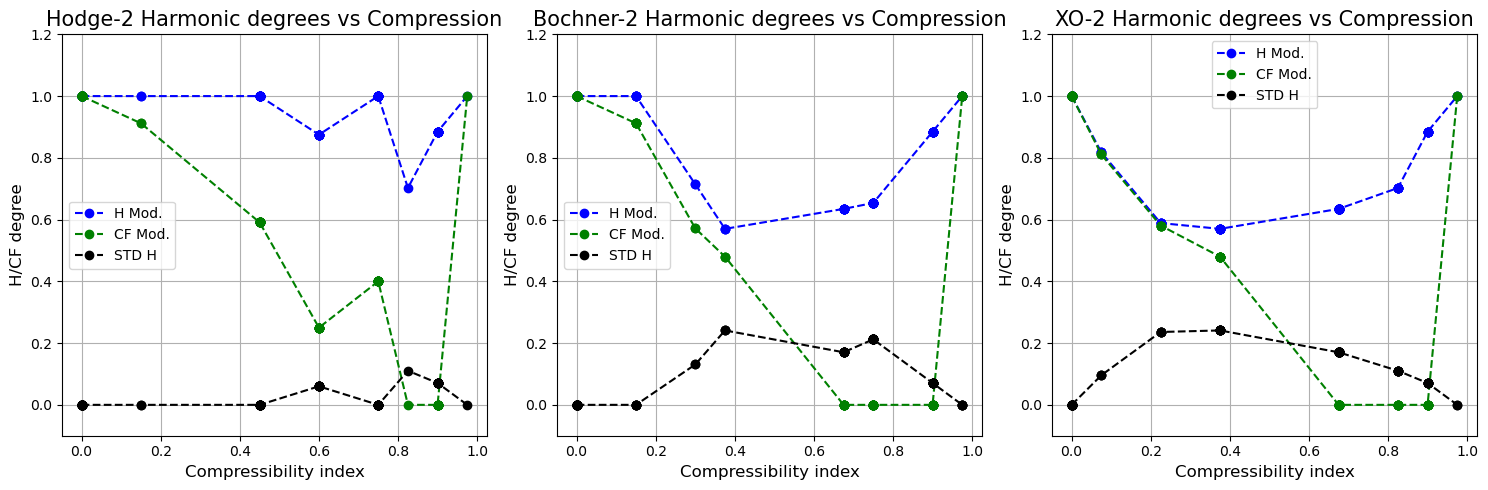

In [10]:
l_h=g_len(g_h)
l_h=1-np.array(l_h)/len(Ag_h.nodes())

l_b=g_len(g_b)
l_b=1-np.array(l_b)/len(Ag_b.nodes())

l_x=g_len(g_x)
l_x=1-np.array(l_x)/len(Ag_x.nodes())

f,ax=plt.subplots(1,3,figsize=(15,5))

ax[0].plot(l_h,M_DEG_H_h,"ob--")
ax[0].plot(l_h,M_DEG_CF_h,"og--")
ax[0].plot(l_h,STD_H_h,"ok--")
ax[0].set_xlabel("Compressibility index")
ax[0].set_ylabel("H/CF degree")
ax[0].set_title("Hodge-2 Harmonic degrees vs Compression", size= 15)
ax[0].legend(["H Mod.","CF Mod.","STD H"], loc = "best")
ax[0].set_ylim([-0.1,1.2])
ax[0].grid()

ax[1].plot(l_b,M_DEG_H_b,"ob--")
ax[1].plot(l_b,M_DEG_CF_b,"og--")
ax[1].plot(l_b,STD_H_b,"ok--")
ax[1].set_xlabel("Compressibility index")
ax[1].set_ylabel("H/CF degree")
ax[1].set_title("Bochner-2 Harmonic degrees vs Compression", size= 15)
ax[1].legend(["H Mod.","CF Mod.","STD H"], loc = "best")
ax[1].set_ylim([-0.1,1.2])
ax[1].grid()

ax[2].plot(l_x,M_DEG_H_x,"ob--")
ax[2].plot(l_x,M_DEG_CF_x,"og--")
ax[2].plot(l_x,STD_H_x,"ok--")
ax[2].set_xlabel("Compressibility index")
ax[2].set_ylabel("H/CF degree")
ax[2].set_title("XO-2 Harmonic degrees vs Compression", size= 15)
ax[2].legend(["H Mod.","CF Mod.","STD H"], loc  = "best")
ax[2].set_ylim([-0.1,1.2])
ax[2].grid()


plt.tight_layout()
f.savefig("Pf2_compression.pdf")

  H  Mod. H  Std. H  CF  Mod. CF  Std. CF
1.0     1.0     0.0 0.1      0.4 1.104182


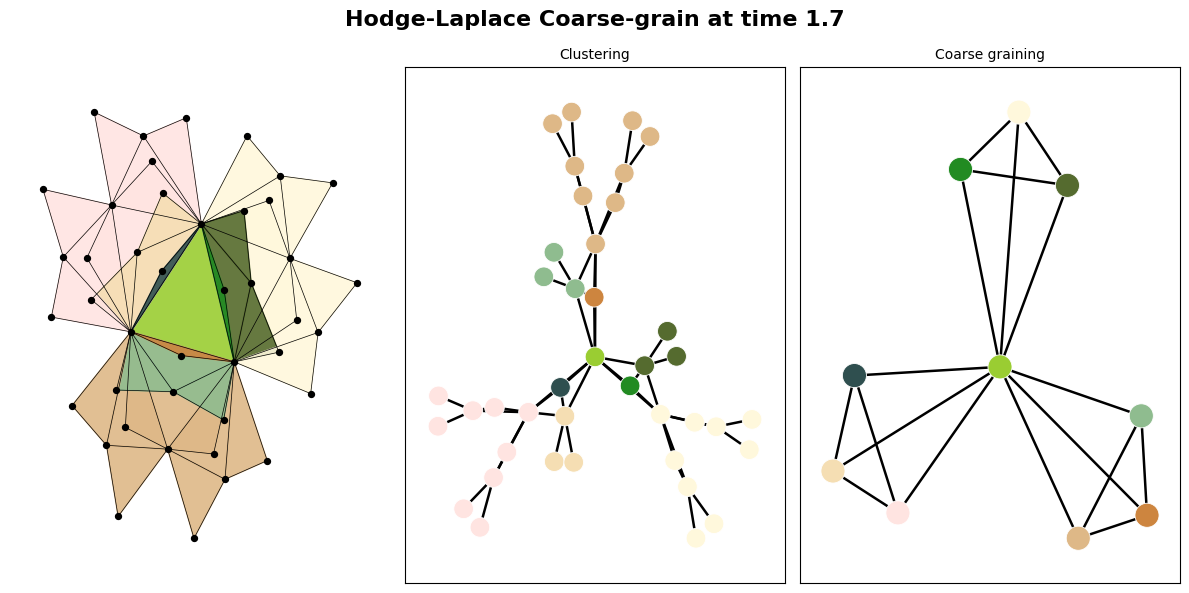

In [57]:
t = 1.7
Ag,G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv, sing_col, colors = higher_order_renormalization(sc,dim=2,t=t,Lap=L2)
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
colors = [colors[n] for n in Ag.nodes()]
sc_layout = nx.spring_layout(nx.from_edgelist(sc["edges"]), iterations=1000)
layout = nx.spring_layout(Ag, iterations=500)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,3,figsize = (12,6))
ax = ax.flatten()

plot_complex(sc,ax = ax[0],face_color=colors,pos=sc_layout,edge_width=0.5,node_size=18,face_alpha=0.9,with_labels=False)

nodes = nx.draw_networkx_nodes(Ag,ax=ax[1],pos=layout,node_color=colors,node_size = 200)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[1],pos=layout, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Clustering")

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[2],pos=lay2,node_color=sing_col,node_size = 300)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[2],pos=lay2, width = 1.8)
ax[2].collections[1].set_alpha(1)
ax[2].collections[0].set_linewidth(0.6) 
ax[2].collections[0].set_edgecolor("#FFFFFF")
ax[2].set_title(f"Coarse graining")
f.suptitle(f"Hodge-Laplace Coarse-grain at time {t}", fontsize=16, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
f.savefig("Pf2_H.pdf")

    H   Mod. H   Std. H  CF  Mod. CF  Std. CF
0.625 0.653846 0.212132 0.0      0.0 1.015701


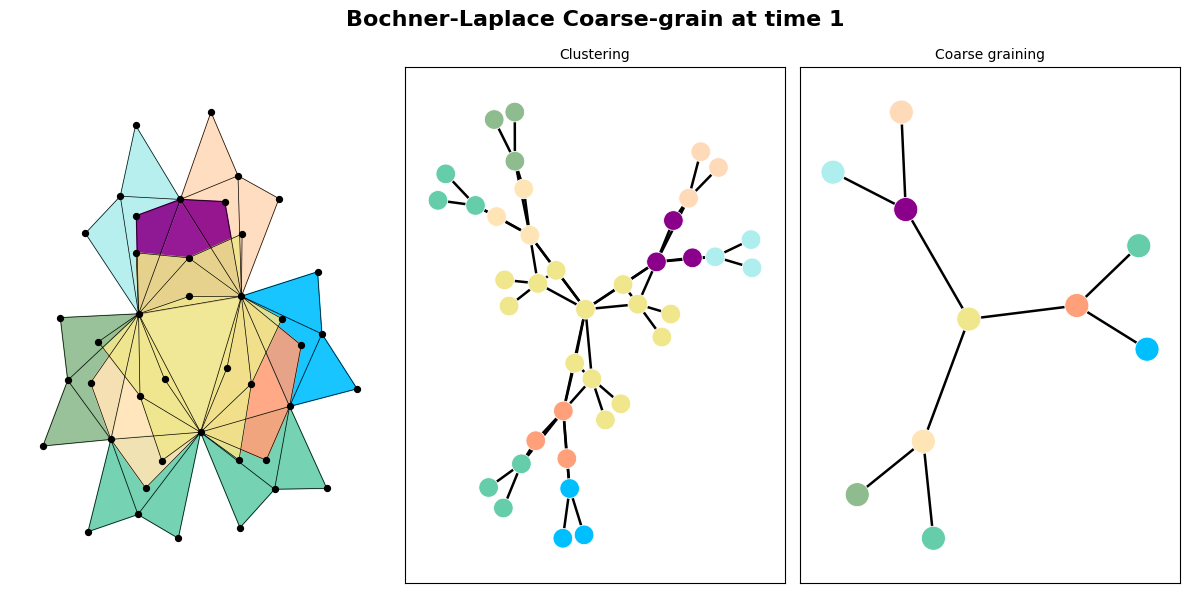

In [58]:
t = 1
Ag,G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv, sing_col, colors = higher_order_renormalization(sc,dim=2,t=t,Lap=B2)
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
colors = [colors[n] for n in Ag.nodes()]
sc_layout = nx.spring_layout(nx.from_edgelist(sc["edges"]), iterations=1000)
layout = nx.spring_layout(Ag, iterations=500)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,3,figsize = (12,6))
ax = ax.flatten()

plot_complex(sc,ax = ax[0],face_color=colors,pos=sc_layout,edge_width=0.5,node_size=18,face_alpha=0.9,with_labels=False)

nodes = nx.draw_networkx_nodes(Ag,ax=ax[1],pos=layout,node_color=colors,node_size = 200)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[1],pos=layout, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Clustering")

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[2],pos=lay2,node_color=sing_col,node_size = 300)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[2],pos=lay2, width = 1.8)
ax[2].collections[1].set_alpha(1)
ax[2].collections[0].set_linewidth(0.6) 
ax[2].collections[0].set_edgecolor("#FFFFFF")
ax[2].set_title(f"Coarse graining")
f.suptitle(f"Bochner-Laplace Coarse-grain at time {t}", fontsize=16, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
f.savefig("Pf2_B.pdf")

    H   Mod. H   Std. H  CF  Mod. CF  Std. CF
0.625 0.634615 0.170283 0.0      0.0 0.838535


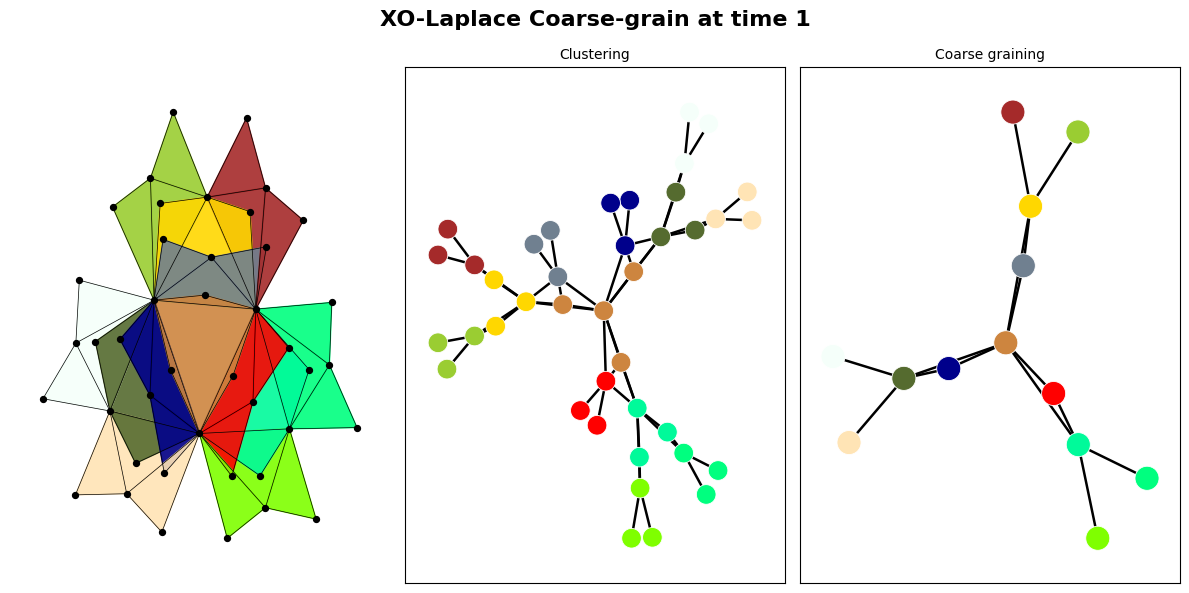

In [60]:
t = 1
Ag,G, deg_h, M_deg_h, std_h, av_h, std_v_h, Not_h, deg_cf, M_deg_cf, std_cf, av_cf, std_v_cf, Not_cf, Gv, sing_col, colors = higher_order_renormalization(sc,dim=2,t=t,Lap=X2)
Values = [deg_h, M_deg_h, std_h, deg_cf, M_deg_cf, std_cf]
Labels = ["H", "Mod. H", "Std. H", "CF", "Mod. CF", "Std. CF"]
df = pd.DataFrame([Values], columns = Labels)
colors = [colors[n] for n in Ag.nodes()]
sc_layout = nx.spring_layout(nx.from_edgelist(sc["edges"]), iterations=1000)
layout = nx.spring_layout(Ag, iterations=500)
lay2=nx.spring_layout(G,iterations=100)
f,ax = plt.subplots(1,3,figsize = (12,6))
ax = ax.flatten()

plot_complex(sc,ax = ax[0],face_color=colors,pos=sc_layout,edge_width=0.5,node_size=18,face_alpha=0.9,with_labels=False)

nodes = nx.draw_networkx_nodes(Ag,ax=ax[1],pos=layout,node_color=colors,node_size = 200)
nodes.set_edgecolor("white")
nx.draw_networkx_edges(Ag,ax=ax[1],pos=layout, width = 1.8)
ax[1].collections[1].set_alpha(1)
ax[1].collections[0].set_linewidth(0.6) 
ax[1].collections[0].set_edgecolor("#FFFFFF") 
ax[1].set_title(f"Clustering")

nodes_2 = nx.draw_networkx_nodes(G,ax=ax[2],pos=lay2,node_color=sing_col,node_size = 300)
nodes_2.set_edgecolor("white")
nx.draw_networkx_edges(G,ax=ax[2],pos=lay2, width = 1.8)
ax[2].collections[1].set_alpha(1)
ax[2].collections[0].set_linewidth(0.6) 
ax[2].collections[0].set_edgecolor("#FFFFFF")
ax[2].set_title(f"Coarse graining")
f.suptitle(f"XO-Laplace Coarse-grain at time {t}", fontsize=16, fontweight="bold") 
plt.tight_layout()
print(df.to_string(index=False))
f.savefig("Pf2_X.pdf")

# Pseudofractal 3D

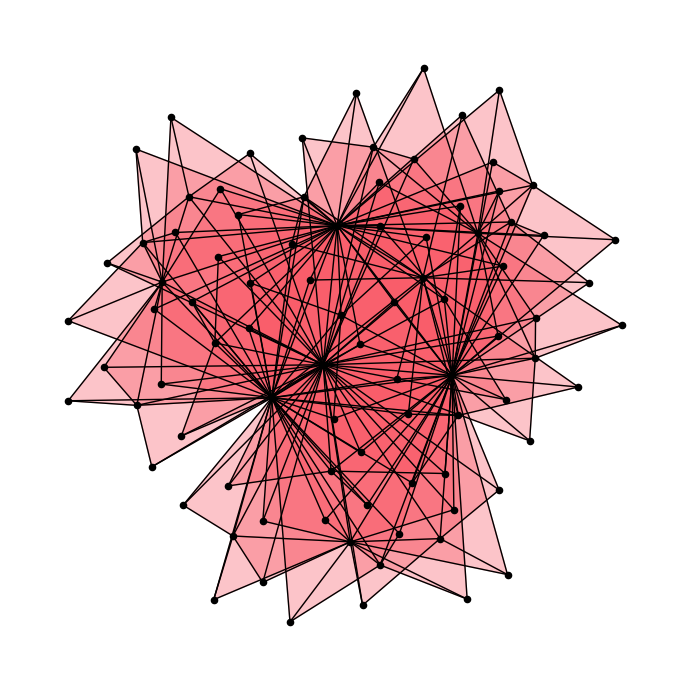

In [25]:
# Building the pseudofractal 3D
sc=pseudofractal_d3(3)
f,axs = plt.subplots(1,1,figsize = (7,7))
plot_complex(sc,ax = axs,face_color=[col],face_alpha=0.2,node_size=20,iterations=1000,with_labels=False)
plt.tight_layout()

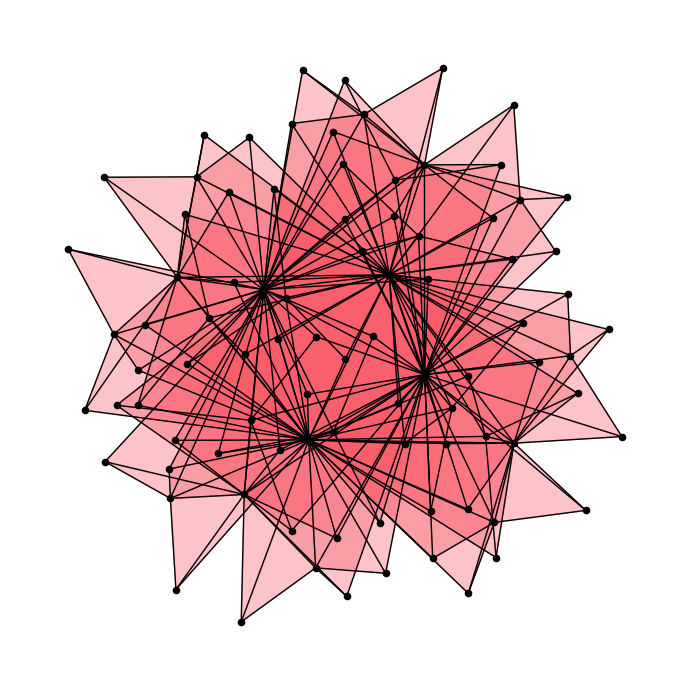

In [26]:
# let's create 2D holes in it, building a new simplicial complex called sc_h
nodes=sc["nodes"]
n0=len(nodes)
edges=sc["edges"]
n1=len(edges)
faces=sc["faces"]
n2=len(faces)


sc_h={'nodes' : nodes,'n0' : n0,'edges' : edges, 'n1' : n1,
        'faces' : faces ,'tetrahedra' : np.array([]),
        '4-simplices' : np.array([]), 'n2' : n2, 'n3' : 0, 'n4' : 0}

f,axs = plt.subplots(1,1,figsize = (7,7))
plot_complex(sc_h,ax = axs,face_color=[col],face_alpha=0.2,node_size=20,iterations=1000,with_labels=False)
plt.tight_layout()

In [27]:
# I consider all the matrices I need
L0, L1, L2, L3, L4, node_dict, edge_dict, face_dict, tet_dict=laplacians(sc)
B2, F2 =fbc(L2)
X2 = XO_laplacian(sc,2,1)
B3, F3 =fbc(L3)
X3 = XO_laplacian(sc,3,2)

# Then the 2-order operators related to sc_h, the complex with the holes
L0_h, L1_h, L2_h, L3_h, L4_h, node_dict_h, edge_dict_h, face_dict_h, tet_dict_h=laplacians(sc_h)
B2_h, F2_h =fbc(L2_h)

In [28]:
# 3D
Ag_h_3, g_h_3, DEG_H_h_3, M_DEG_H_h_3, STD_H_h_3, AV_H_h_3, STD_V_H_h_3, NOT_H_h_3, DEG_CF_h_3, M_DEG_CF_h_3, STD_CF_h_3, AV_CF_h_3, STD_V_CF_h_3, NOT_CF_h_3, gV_h_3, t_span_h_3 = higher_order_H_CF_curves(sc,n=100,dim=3,Lap=L3)
Ag_b_3, g_b_3, DEG_H_b_3, M_DEG_H_b_3, STD_H_b_3, AV_H_b_3, STD_V_H_b_3, NOT_H_b_3, DEG_CF_b_3, M_DEG_CF_b_3, STD_CF_b_3, AV_CF_b_3, STD_V_CF_b_3, NOT_CF_b_3, gV_b_3, t_span_b_3 = higher_order_H_CF_curves(sc,n=100,dim=3,Lap=B3)
Ag_x_3, g_x_3, DEG_H_x_3, M_DEG_H_x_3, STD_H_x_3, AV_H_x_3, STD_V_H_x_3, NOT_H_x_3, DEG_CF_x_3, M_DEG_CF_x_3, STD_CF_x_3, AV_CF_x_3, STD_V_CF_x_3, NOT_CF_x_3, gV_x_3, t_span_x_3 = higher_order_H_CF_curves(sc,n=100,dim=3,Lap=X3)

In [29]:
# 2D adjacency
Ag_h, g_h, DEG_H_h, M_DEG_H_h, STD_H_h, AV_H_h, STD_V_H_h, NOT_H_h, DEG_CF_h, M_DEG_CF_h, STD_CF_h, AV_CF_h, STD_V_CF_h, NOT_CF_h, gV_h, t_span_h = higher_order_H_CF_curves(sc,n=100,dim=2,Lap=L2)
Ag_b, g_b, DEG_H_b, M_DEG_H_b, STD_H_b, AV_H_b, STD_V_H_b, NOT_H_b, DEG_CF_b, M_DEG_CF_b, STD_CF_b, AV_CF_b, STD_V_CF_b, NOT_CF_b, gV_b, t_span_b = higher_order_H_CF_curves(sc,n=100,dim=2,Lap=B2)
Ag_x, g_x, DEG_H_x, M_DEG_H_x, STD_H_x, AV_H_x, STD_V_H_x, NOT_H_x, DEG_CF_x, M_DEG_CF_x, STD_CF_x, AV_CF_x, STD_V_CF_x, NOT_CF_x, gV_x, t_span_x = higher_order_H_CF_curves(sc,n=100,dim=2,Lap=X2)

In [30]:
# 2D holes
Ag_h_H, g_h_H, DEG_H_h_H, M_DEG_H_h_H, STD_H_h_H, AV_H_h_H, STD_V_H_h_H, NOT_H_h_H, DEG_CF_h_H, M_DEG_CF_h_H, STD_CF_h_H, AV_CF_h_H, STD_V_CF_h_H, NOT_CF_h_H, gV_h_H, t_span_h_H = higher_order_H_CF_curves(sc_h,n=100,dim=2,Lap=L2_h)
Ag_b_H, g_b_H, DEG_H_b_H, M_DEG_H_b_H, STD_H_b_H, AV_H_b_H, STD_V_H_b_H, NOT_H_b_H, DEG_CF_b_H, M_DEG_CF_b_H, STD_CF_b_H, AV_CF_b_H, STD_V_CF_b_H, NOT_CF_b_H, gV_b_H, t_span_b_H = higher_order_H_CF_curves(sc_h,n=100,dim=2,Lap=B2_h)

In [31]:
# 2D //
Ag_h_p, g_h_p, DEG_H_h_p, M_DEG_H_h_p, STD_H_h_p, AV_H_h_p, STD_V_H_h_p, NOT_H_h_p, DEG_CF_h_p, M_DEG_CF_h_p, STD_CF_h_p, AV_CF_h_p, STD_V_CF_h_p, NOT_CF_h_p, gV_h_p, t_span_h_p = higher_order_H_CF_curves_p(sc,n=100,dim=2,Lap=L2)
Ag_b_p, g_b_p, DEG_H_b_p, M_DEG_H_b_p, STD_H_b_p, AV_H_b_p, STD_V_H_b_p, NOT_H_b_p, DEG_CF_b_p, M_DEG_CF_b_p, STD_CF_b_p, AV_CF_b_p, STD_V_CF_b_p, NOT_CF_b_p, gV_b_p, t_span_b_p = higher_order_H_CF_curves_p(sc,n=100,dim=2,Lap=B2)

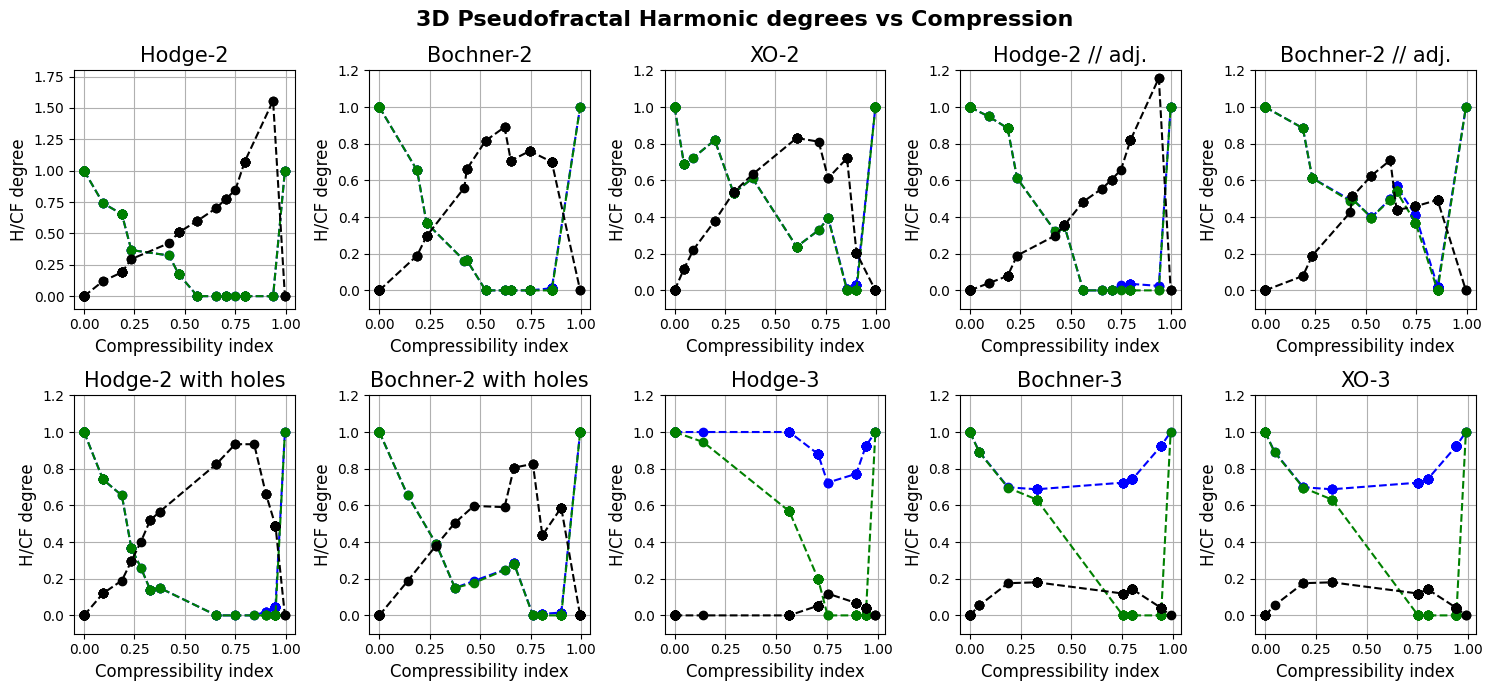

In [46]:
# 2D
l_h=g_len(g_h)
l_h=1-np.array(l_h)/len(Ag_h.nodes())

l_b=g_len(g_b)
l_b=1-np.array(l_b)/len(Ag_b.nodes())

l_x=g_len(g_x)
l_x=1-np.array(l_x)/len(Ag_x.nodes())


# 2D holes
l_h_H=g_len(g_h_H)
l_h_H=1-np.array(l_h_H)/len(Ag_h_H.nodes())

l_b_H=g_len(g_b_H)
l_b_H=1-np.array(l_b_H)/len(Ag_b_H.nodes())


# 3D
l_h_3=g_len(g_h_3)
l_h_3=1-np.array(l_h_3)/len(Ag_h_3.nodes())

l_b_3=g_len(g_b_3)
l_b_3=1-np.array(l_b_3)/len(Ag_b_3.nodes())

l_x_3=g_len(g_x_3)
l_x_3=1-np.array(l_x_3)/len(Ag_x_3.nodes())


# 2D //
l_h_p=g_len(g_h_p)
l_h_p=1-np.array(l_h_p)/len(Ag_h_p.nodes())

l_b_p=g_len(g_b_p)
l_b_p=1-np.array(l_b_p)/len(Ag_b_p.nodes())



f,ax=plt.subplots(2,5,figsize=(15,7))
ax = ax.flatten()
ax[0].plot(l_h,M_DEG_H_h,"ob--")
ax[0].plot(l_h,M_DEG_CF_h,"og--")
ax[0].plot(l_h,STD_H_h,"ok--")
ax[0].set_xlabel("Compressibility index")
ax[0].set_ylabel("H/CF degree")
ax[0].set_title("Hodge-2", size= 15)
#ax[0].legend(["H Mod.","CF Mod.","STD H"], loc = "best")
ax[0].set_ylim([-0.1,1.8])
ax[0].grid()

ax[1].plot(l_b,M_DEG_H_b,"ob--")
ax[1].plot(l_b,M_DEG_CF_b,"og--")
ax[1].plot(l_b,STD_H_b,"ok--")
ax[1].set_xlabel("Compressibility index")
ax[1].set_ylabel("H/CF degree")
ax[1].set_title("Bochner-2", size= 15)
#ax[1].legend(["H Mod.","CF Mod.","STD H"], loc = "best")
ax[1].set_ylim([-0.1,1.2])
ax[1].grid()

ax[2].plot(l_x,M_DEG_H_x,"ob--")
ax[2].plot(l_x,M_DEG_CF_x,"og--")
ax[2].plot(l_x,STD_H_x,"ok--")
ax[2].set_xlabel("Compressibility index")
ax[2].set_ylabel("H/CF degree")
ax[2].set_title("XO-2", size= 15)
#ax[2].legend(["H Mod.","CF Mod.","STD H"], loc  = "best")
ax[2].set_ylim([-0.1,1.2])
ax[2].grid()

ax[3].plot(l_h_p,M_DEG_H_h_p,"ob--")
ax[3].plot(l_h_p,M_DEG_CF_h_p,"og--")
ax[3].plot(l_h_p,STD_H_h_p,"ok--")
ax[3].set_xlabel("Compressibility index")
ax[3].set_ylabel("H/CF degree")
ax[3].set_title("Hodge-2 // adj.", size= 15)
#ax[3].legend(["H Mod.","CF Mod.","STD H"], loc = "best")
ax[3].set_ylim([-0.1,1.2])
ax[3].grid()

ax[4].plot(l_b_p,M_DEG_H_b_p,"ob--")
ax[4].plot(l_b_p,M_DEG_CF_b_p,"og--")
ax[4].plot(l_b_p,STD_H_b_p,"ok--")
ax[4].set_xlabel("Compressibility index")
ax[4].set_ylabel("H/CF degree")
ax[4].set_title("Bochner-2 // adj.", size= 15)
#ax[4].legend(["H Mod.","CF Mod.","STD H"], loc = "best")
ax[4].set_ylim([-0.1,1.2])
ax[4].grid()

ax[5].plot(l_h_H,M_DEG_H_h_H,"ob--")
ax[5].plot(l_h_H,M_DEG_CF_h_H,"og--")
ax[5].plot(l_h_H,STD_H_h_H,"ok--")
ax[5].set_xlabel("Compressibility index")
ax[5].set_ylabel("H/CF degree")
ax[5].set_title("Hodge-2 with holes", size= 15)
#ax[5].legend(["H Mod.","CF Mod.","STD H"], loc = "best")
ax[5].set_ylim([-0.1,1.2])
ax[5].grid()

ax[6].plot(l_b_H,M_DEG_H_b_H,"ob--")
ax[6].plot(l_b_H,M_DEG_CF_b_H,"og--")
ax[6].plot(l_b_H,STD_H_b_H,"ok--")
ax[6].set_xlabel("Compressibility index")
ax[6].set_ylabel("H/CF degree")
ax[6].set_title("Bochner-2 with holes", size= 15)
#ax[6].legend(["H Mod.","CF Mod.","STD H"], loc = "best")
ax[6].set_ylim([-0.1,1.2])
ax[6].grid()


ax[7].plot(l_h_3,M_DEG_H_h_3,"ob--")
ax[7].plot(l_h_3,M_DEG_CF_h_3,"og--")
ax[7].plot(l_h_3,STD_H_h_3,"ok--")
ax[7].set_xlabel("Compressibility index")
ax[7].set_ylabel("H/CF degree")
ax[7].set_title("Hodge-3", size= 15)
#ax[7].legend(["H Mod.","CF Mod.","STD H"], loc = "best")
ax[7].set_ylim([-0.1,1.2])
ax[7].grid()

ax[8].plot(l_b_3,M_DEG_H_b_3,"ob--")
ax[8].plot(l_b_3,M_DEG_CF_b_3,"og--")
ax[8].plot(l_b_3,STD_H_b_3,"ok--")
ax[8].set_xlabel("Compressibility index")
ax[8].set_ylabel("H/CF degree")
ax[8].set_title("Bochner-3", size= 15)
#ax[8].legend(["H Mod.","CF Mod.","STD H"], loc = "best")
ax[8].set_ylim([-0.1,1.2])
ax[8].grid()

ax[9].plot(l_x_3,M_DEG_H_x_3,"ob--")
ax[9].plot(l_x_3,M_DEG_CF_x_3,"og--")
ax[9].plot(l_x_3,STD_H_x_3,"ok--")
ax[9].set_xlabel("Compressibility index")
ax[9].set_ylabel("H/CF degree")
ax[9].set_title("XO-3", size= 15)
#ax[9].legend(["H Mod.","CF Mod.","STD H"], loc  = "best")
ax[9].set_ylim([-0.1,1.2])
ax[9].grid()


f.suptitle("3D Pseudofractal Harmonic degrees vs Compression", fontsize=16, fontweight="bold")

plt.tight_layout()
f.savefig("Panel_Pseudofractal_3D.pdf")